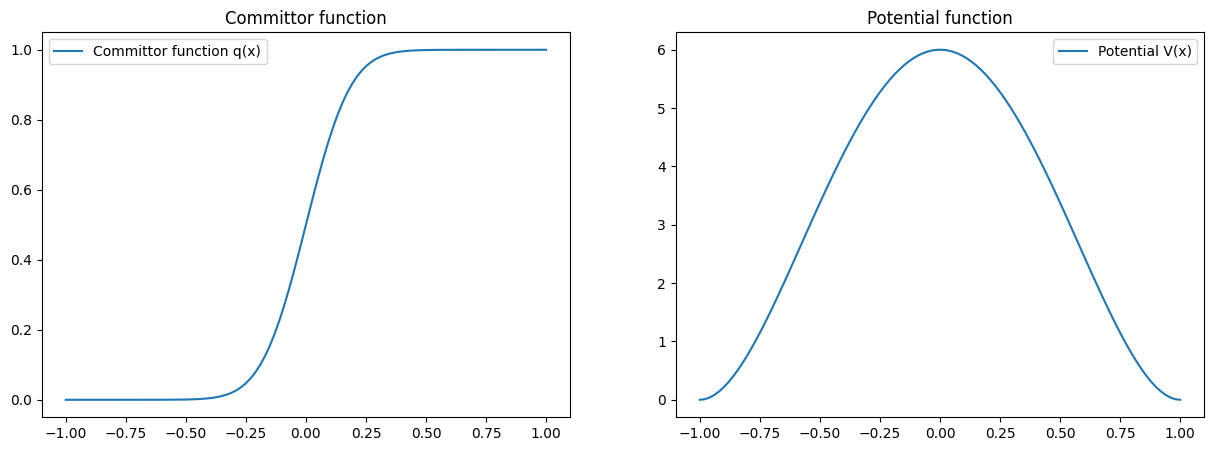

In [1]:
import numpy as np
from scipy.integrate import quad, cumulative_trapezoid
from scipy.interpolate import interp1d

a = 1 
b = 4

coeff = 6
V_poly = coeff * np.poly1d([1, 0 , -2, 0, 1])
D_poly = coeff * np.poly1d([1, 0 , -2, 0,1])
A, B, x0 = -1,1, -1+ 0.01

beta, eps, tol = 2, 1e-8, 1e-3
N = 2000 # Résolution pour la mémoisation par interpolation

x_grid = np.linspace(A, B, N)


dV_poly, dD_poly = np.polyder(V_poly), np.polyder(D_poly)
ddD_poly = np.polyder(dD_poly)

V_vals = V_poly(x_grid)
g_vals = 0.5 * ddD_poly(x_grid) - 0.5 * beta * dD_poly(x_grid) * dV_poly(x_grid)
def qfunc(x):
    return quad(lambda x: np.exp(beta * V_poly(x)), A, x)[0]/quad(lambda x: np.exp(beta * V_poly(x)), A, B)[0]

#plotting the committor function and potential
import matplotlib.pyplot as plt
x_plot = np.linspace(A, B, 100)
q_plot = np.array([qfunc(x) for x in x_plot])
V_plot = V_poly(x_plot)
fig, axes = plt.subplots(1, 2, figsize=(15,5))
axes[0].plot(x_plot, q_plot, label='Committor function q(x)')
axes[0].set_title('Committor function')
axes[0].legend()
axes[1].plot(x_plot, V_plot, label='Potential V(x)')
axes[1].set_title('Potential function')
axes[1].legend()




In [2]:
# Calcul de q_unnorm et sa constante de normalisation
q_p_vals = np.exp(beta * V_vals)
q_int_vals = cumulative_trapezoid(q_p_vals, x_grid, initial=0)
C = 1.0 / q_int_vals[-1]

# q(x) et M(x) sur la grille
q_vals = C * q_int_vals
M_vals = (q_vals**2) * np.exp(-beta * V_vals)

# On crée des fonctions interpolées pour un accès continu
q_func = interp1d(x_grid, q_vals, kind='cubic', fill_value="extrapolate")
M_func = interp1d(x_grid, M_vals, kind='cubic', fill_value="extrapolate")

In [3]:
# Intégrale interne pour u
integrand_u = M_vals * g_vals
I_u_vals = cumulative_trapezoid(integrand_u, x_grid, initial=0)

# u_prime (attention à la division par M qui peut tendre vers 0 en A)
u_p_vals = np.zeros_like(x_grid)
mask = M_vals > 1e-15 
u_p_vals[mask] = -beta * I_u_vals[mask] / M_vals[mask]

# u(x) par intégration de u_prime (de x à B)
# Note : int_x^B f = int_A^B f - int_A^x f
u_cum = cumulative_trapezoid(u_p_vals, x_grid, initial=0)
u_vals = -(u_cum[-1] - u_cum)
u_func = interp1d(x_grid, u_vals, kind='cubic', fill_value="extrapolate")

In [4]:
# Intégrale interne pour w
integrand_w = M_vals * g_vals * u_vals
I_w_vals = cumulative_trapezoid(integrand_w, x_grid, initial=0)

# w_prime
w_p_vals = np.zeros_like(x_grid)
w_p_vals[mask] = -2.0 * beta * I_w_vals[mask] / M_vals[mask]

# w(x)
w_cum = cumulative_trapezoid(w_p_vals, x_grid, initial=0)
w_vals = -(w_cum[-1] - w_cum)
w_func = interp1d(x_grid, w_vals, kind='cubic', fill_value="extrapolate")

In [5]:
u_x0 = u_func(x0)
w_x0 = w_func(x0)
variance = w_x0 - (u_x0**2)
E_a = -0.5 * beta * (D_poly(B) - D_poly(x0)) + u_x0

print(f"Bêta = {beta}")
print(f"Esperance E*[a(X)] = {E_a:.5f}")
print(f"Variance V*[a(X)] = {variance:.5f}")
print(f"probabilité de transition q(x0) ={q_func(x0)}")
n_rep = variance **2 

Bêta = 2
Esperance E*[a(X)] = -11.47928
Variance V*[a(X)] = 10.68287
probabilité de transition q(x0) =1.6718600814760378e-07


In [6]:
n_rep

np.float64(114.12364180366183)